<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_66_adaboost_Practical_Code_demo/Lecture_66_adaboost_hyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
# Generate synthetic data for classification
np.random.seed(42)
X, y = make_circles(n_samples=500, noise=0.35, factor=0.1, random_state=42)

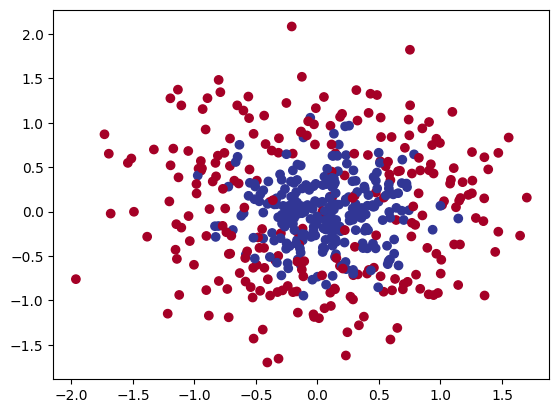

In [3]:
# Visualize the generated data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [4]:
# Import AdaBoostClassifier and cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

# Initialize AdaBoostClassifier with default parameters
abc = AdaBoostClassifier()

# Perform cross-validation to evaluate the model's accuracy
np.mean(cross_val_score(abc, X, y, scoring='accuracy', cv=10))

np.float64(0.812)

In [5]:
# Train the AdaBoostClassifier model on the data
abc.fit(X, y)

AdaBoostClassifier()

In [6]:
# Define a function to plot the decision boundary of a classifier
def plot_decision_boundary(clf):
  plt.figure(figsize=(12, 8))
  x_range = np.linspace(X.min(), X.max(), 100)
  xx1, xx2 = np.meshgrid(x_range, x_range)
  y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
  y_hat = y_hat.reshape(xx1.shape)
  plt.contourf(xx1, xx2, y_hat, cmap=plt.cm.RdYlBu,alpha=0.2)
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, alpha=.7)
  plt.title('Adaboost classifier')
  plt.show()

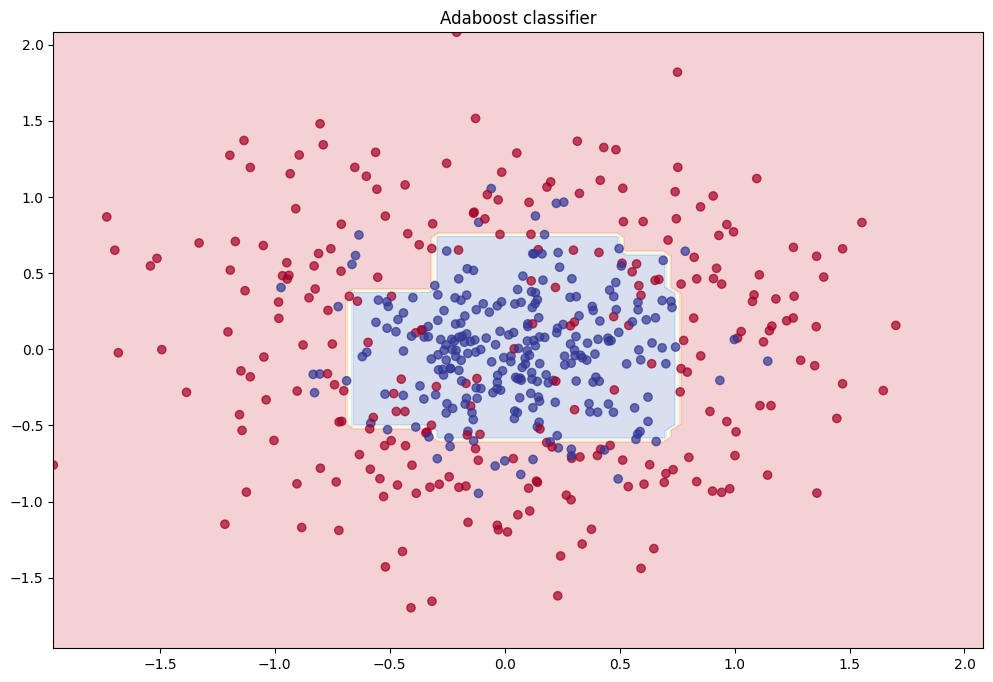

In [7]:
# Plot the decision boundary for the trained AdaBoostClassifier with default parameters
plot_decision_boundary(abc)

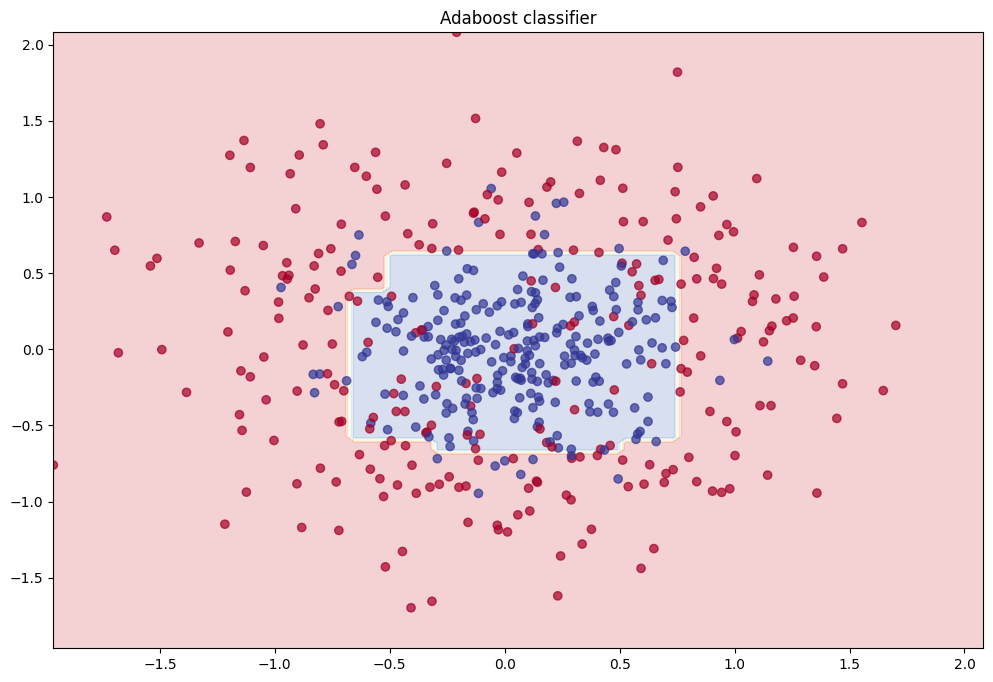

In [13]:
# Initialize AdaBoostClassifier with specified parameters (n_estimators and learning_rate)
abc = AdaBoostClassifier(n_estimators=500, learning_rate=0.1)
# Train the model with the new parameters
abc.fit(X, y)
# Plot the decision boundary for the retrained model
plot_decision_boundary(abc)

In [14]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']

# Initialize GridSearchCV with the AdaBoostClassifier and parameter grid
grid_search = GridSearchCV(estimator=abc, param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')
# Perform the grid search to find the best parameters
grid_result = grid_search.fit(X, y)

In [15]:
# Print the best accuracy score and the corresponding best parameters found by GridSearchCV
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.832000 using {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}
